# F6 — Week 10 Performance Review

**Objective**: Review the optimisation performance of F6 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F6 (5D input, 1D output, maximisation)

This notebook loads the Week 10 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 6
N_DIMS = 5
N_INITIAL = 20
WEEK = 10
USE_LOG_SCALE = False
DATA_DIR = '../../data/f6/'

## Step 1 — Load Data

In [2]:
# Load Week 10 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F6 — Week 10 Data Summary
  Input dimensions:  5
  Total samples:     30
  Initial samples:   20
  Submissions:       10
  Input shape:       (30, 5)
  Output shape:      (30,)
  Best output:       -0.11149
  Worst output:      -2.57117

Sample | x1 | x2 | x3 | x4 | x5 | y
-------------------------------------------------------------------------------------
   1(init) | 0.728186 | 0.154693 | 0.732552 | 0.693997 | 0.056401 | -0.714265
   2(init) | 0.242384 | 0.844100 | 0.577809 | 0.679021 | 0.501953 | -1.20996
   3(init) | 0.729523 | 0.748106 | 0.679775 | 0.356552 | 0.671054 | -1.6722
   4(init) | 0.770620 | 0.114404 | 0.046780 | 0.648324 | 0.273549 | -1.53606
   5(init) | 0.618812 | 0.331802 | 0.187288 | 0.756238 | 0.328835 | -0.829237
   6(init) | 0.784958 | 0.910682 | 0.708120 | 0.959225 | 0.004911 | -1.24705
   7(init) | 0.145111 | 0.896685 | 0.896322 | 0.726272 | 0.236272 | -1.23379
   8(init) | 0.945069 | 0.288459 | 0.978806 | 0.961656 | 0.598016 | -1.69434
   9(init) | 0.125720 |

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

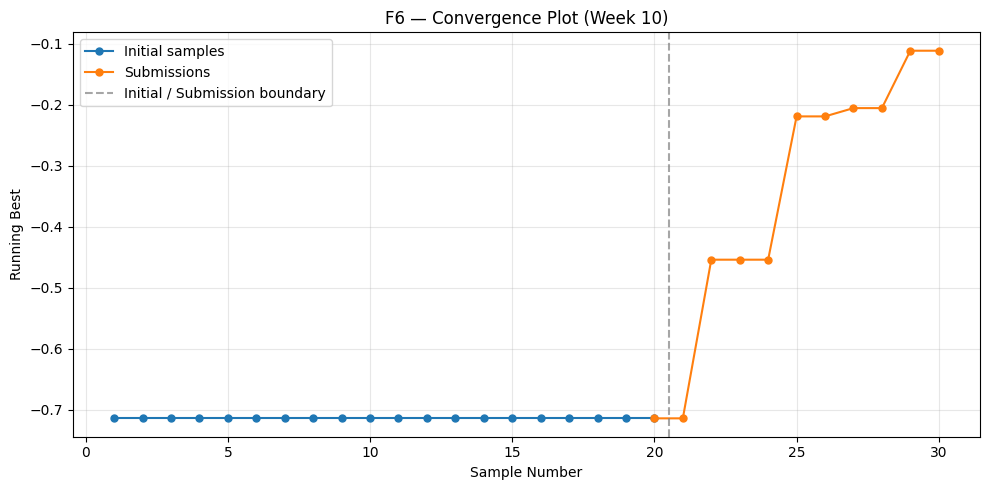

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

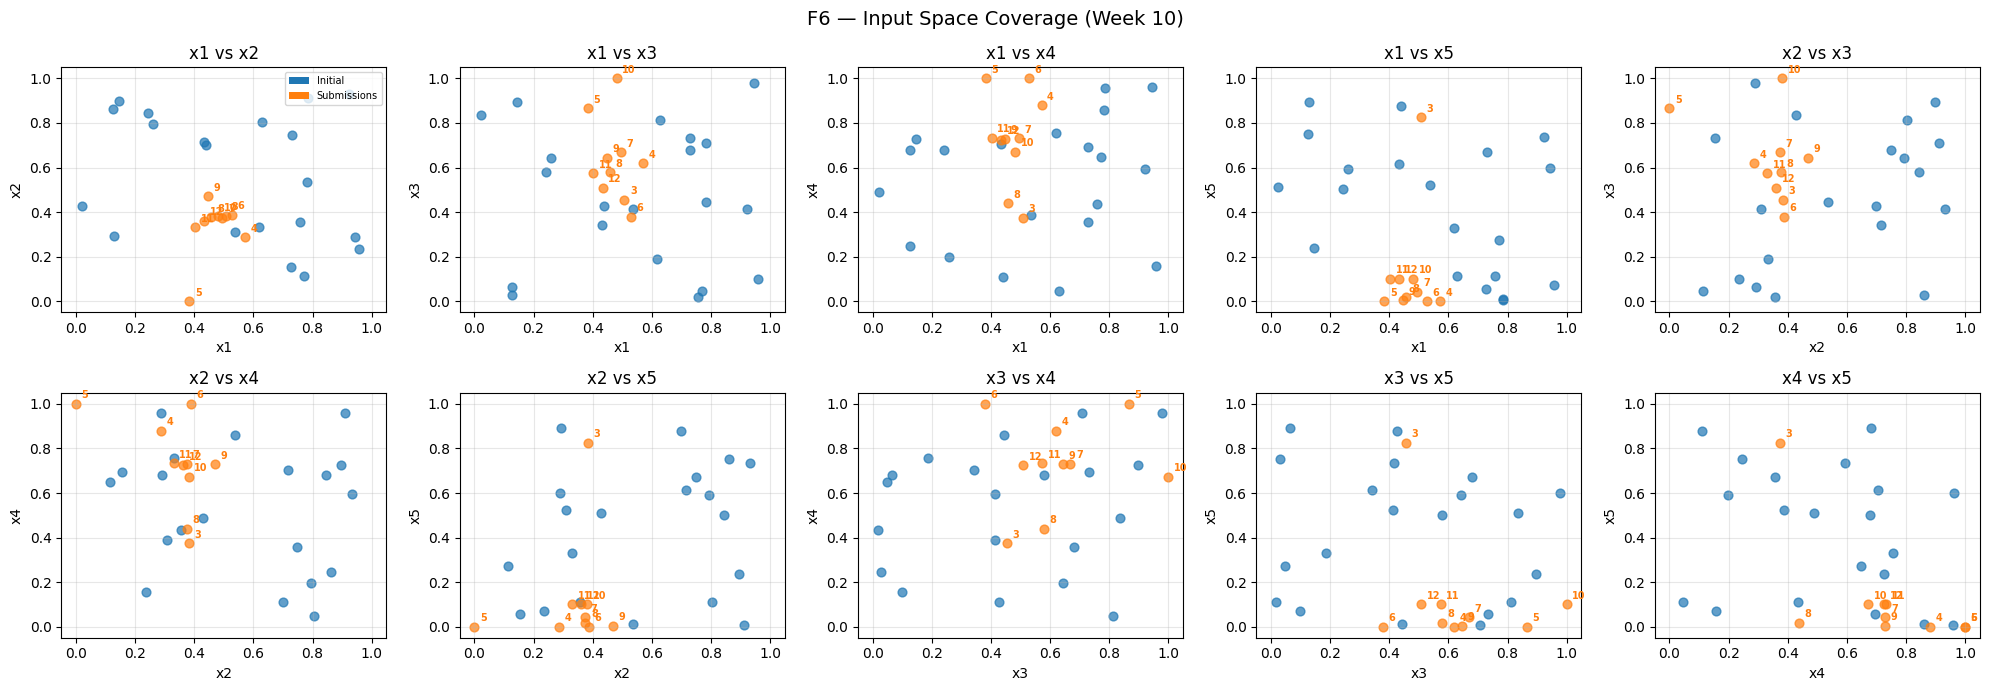

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: SFGP Matérn-1.5 ARD, noise_lb=1e-2
- **Acquisition**: qLogNEI q=4, rank-based interior penalty
- **Key hyperparameters**: 50 restarts, 3000 raw samples, milk ≥ 0.10 constraint

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     -0.714265
Best value (final):       -0.11149
Improvements:             4/10
Max consecutive no-improve: 2
Stalling (≥3 consec):     False

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |       -1.44505 |      -0.714265 | ✗
   4 |       -0.45413 |       -0.45413 | ✓
   5 |       -0.94577 |       -0.45413 | ✗
   6 |      -0.636347 |       -0.45413 | ✗
   7 |      -0.219187 |      -0.219187 | ✓
   8 |      -0.606701 |      -0.219187 | ✗
   9 |        -0.2056 |        -0.2056 | ✓
  10 |      -0.593202 |        -0.2056 | ✗
  11 |       -0.11149 |       -0.11149 | ✓
  12 |      -0.137238 |       -0.11149 | ✗


### Evaluation

F6 is the **best-performing function** with **4 improvements** in 10 submission rounds and **no stalling** (maximum 2 consecutive non-improving). The best value moved from -0.7143 (initial) to -0.1115 — substantial progress towards zero in this all-negative landscape.

Key observations:
- 4/10 submissions improved the running best — the highest improvement rate across all functions
- Maximum only 2 consecutive non-improving submissions — the only function not flagged as stalling
- The rank-based interior penalty with milk ≥ 0.10 constraint is effectively balancing feasibility and optimality
- The negative outputs trending towards zero indicate the surrogate is correctly modelling the landscape
- 5D input space with 10 pair plots provides rich visualisation of the exploration pattern

**Stalling status**: NO — maximum 2 consecutive submissions without improvement (below threshold of 3).

## Step 5 — Proposed Strategy Improvements

F6 is the best performer (4/10 improvements, no stalling). Minor refinements to maintain progress:

1. **Maintain current approach** — The SFGP Matérn-1.5 ARD with rank-based interior penalty is working well. Major changes could disrupt the positive trajectory.

2. **Consider tightening the milk constraint** — If feasibility is well-established, the milk ≥ 0.10 threshold could be increased slightly (e.g., 0.12) to focus on higher-quality feasible regions.

3. **Reduce noise_lb from 1e-2 to 1e-3** — The relatively high noise floor may be smoothing out the posterior too much, preventing fine-grained local improvement near the current best.

4. **Review IP steepness parameter** — The penalty steepness controls how sharply infeasible regions are penalised. Fine-tuning this could improve the balance between exploration of the feasible boundary and interior exploitation.

5. **Increase raw samples to 5000** — With 5D input space and 30 total samples, the acquisition surface is complex. More seed points help find better candidates.

**Priority**: LOW — F6 is performing well. Changes should be conservative to avoid disrupting progress.